<a href="https://colab.research.google.com/github/tomaszwienke-lgtm/learning-git-task/blob/master/Zadanie_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from google.colab import files
uploaded = files.upload()
print("Przesłane pliki:", list(uploaded.keys()))

Saving diabetes.csv to diabetes (2).csv
Przesłane pliki: ['diabetes (2).csv']


#Cel projektu
W tym notebooku zbudujemy uniwersalny potok przetwarzania danych (Pipeline), a następnie porównamy działanie różnych algorytmów klasyfikacji na zbiorze diabetes.csv.
Wykorzystamy własną funkcję do oceny modeli (calculate_metrics) oraz automatyczny preprocessor rozpoznający typy kolumn.

In [16]:
%%writefile ml_utils.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, f1_score, roc_auc_score

def calculate_metrics(model, name, X_checked, y_checked, models_list=None, names_list=None, probas_list=None, metrics_df=None):
    """
    Oblicza metryki klasyfikacji, rysuje macierz pomyłek i krzywą ROC.
    Porównuje wiele modeli, jeśli podano odpowiednie listy.
    """
    # Inicjalizacja list, jeśli nie podano
    if models_list is None:
        models_list = []
    if names_list is None:
        names_list = []
    if probas_list is None:
        probas_list = []
    if metrics_df is None:
        metrics_df = pd.DataFrame(columns=['Model', 'F1_score', 'AUC'])

    # Dodajemy model do list
    models_list.append(model)
    names_list.append(name)

    # Predykcje
    predictions = model.predict(X_checked)
    predictions_proba = model.predict_proba(X_checked)[:, 1]
    probas_list.append(predictions_proba)

    # 1. Raport klasyfikacji
    print(f"\n===== {name} =====")
    print(classification_report(y_checked, predictions))

    # 2. Macierz pomyłek
    plt.figure()
    cm = confusion_matrix(y_checked, predictions)
    ax = sns.heatmap(cm, annot=True, cmap='Blues', fmt='.0f')
    ax.set_title(f'Macierz pomyłek - {name}')
    ax.set_xlabel('Przewidywane')
    ax.set_ylabel('Rzeczywiste')
    plt.show()

    # 3. Krzywa ROC
    plt.figure(figsize=(6,6))
    plt.plot([0,1], [0,1], 'k--')
    for mod, mod_name, proba in zip(models_list, names_list, probas_list):
        fpr, tpr, _ = roc_curve(y_checked, proba)
        auc = roc_auc_score(y_checked, proba)
        plt.plot(fpr, tpr, label=f"{mod_name} (AUC={auc:.3f})")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Porównanie krzywych ROC')
    plt.legend(loc='lower right')
    plt.show()

    # 4. Dodanie do ramki z metrykami
    f1 = f1_score(y_checked, predictions)
    auc = roc_auc_score(y_checked, predictions_proba)
    new_row = pd.DataFrame({'Model': [name], 'F1_score': [f1], 'AUC': [auc]})
    metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

    return metrics_df

Overwriting ml_utils.py


Import bibliotek i konfiguracja

In [17]:
# ---------- Importy ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn – pipeline i preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn import set_config

# Modele
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

# Nasza własna funkcja do oceny modeli
from ml_utils import calculate_metrics

# Ustawienie, aby transformatory zwracały DataFrame (zachowujemy nazwy kolumn)
set_config(transform_output="pandas")

Wczytanie danych i szybki podgląd

In [18]:
# ---------- Wczytanie danych ----------
df = pd.read_csv('diabetes.csv')
print(f"Zbiór zawiera {df.shape[0]} wierszy i {df.shape[1]} kolumn.")
print("Pierwsze 5 wierszy:")
display(df.head())

# Podstawowe informacje
print("\nTypy danych:")
print(df.dtypes.value_counts())
print("\nLiczba braków w kolumnach:")
print(df.isnull().sum())

Zbiór zawiera 15000 wierszy i 10 kolumn.
Pierwsze 5 wierszy:


,PatientID,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age,Diabetic
0,1354778,0,171,80,34,23,43.509726,1.213191,21,0
1,1147438,8,92,93,47,36,21.240576,0.158365,23,0
2,1640031,7,115,47,52,35,41.511523,0.079019,23,0
3,1883350,9,103,78,25,304,29.582192,1.282870,43,1
4,1424119,1,85,59,27,35,42.604536,0.549542,22,0



Typy danych:
int64      8
float64    2
Name: count, dtype: int64

Liczba braków w kolumnach:
PatientID                 0
Pregnancies               0
PlasmaGlucose             0
DiastolicBloodPressure    0
TricepsThickness          0
SerumInsulin              0
BMI                       0
DiabetesPedigree          0
Age                       0
Diabetic                  0
dtype: int64


 Podział na zbiór treningowy i testowy

In [19]:
# ---------- Cechy i cel ----------
X = df.drop('Diabetic', axis=1)
y = df['Diabetic']

# Podział z zachowaniem proporcji klas (stratyfikacja)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Trening: {X_train.shape}, Test: {X_test.shape}")
print(f"Proporcje klas w treningu:\n{y_train.value_counts(normalize=True)}")

Trening: (11250, 9), Test: (3750, 9)
Proporcje klas w treningu:
Diabetic
0    0.666667
1    0.333333
Name: proportion, dtype: float64


Uniwersalny preprocessor

In [20]:
# ---------- Preprocessing ----------
# Potok dla kolumn numerycznych
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Potok dla kolumn kategorycznych (na wszelki wypadek)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# ColumnTransformer – automatyczny podział na podstawie typów danych
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, make_column_selector(dtype_include=np.number)),
    ('cat', categorical_transformer, make_column_selector(dtype_include=['object', 'category']))
])

print("Preprocessor gotowy.")

Preprocessor gotowy.


Definicja modeli do porównania

In [21]:
# ---------- Modele ----------
models = {
    'Regresja logistyczna': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42),     # probability=True dla krzywej ROC
    'KNN': KNeighborsClassifier(),
    'Drzewo decyzyjne': DecisionTreeClassifier(random_state=42),
    'Las losowy': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

Trenowanie, ocena i porównanie modeli


===== Regresja logistyczna =====
              precision    recall  f1-score   support

           0       0.81      0.88      0.85      2500
           1       0.72      0.60      0.65      1250

    accuracy                           0.79      3750
   macro avg       0.77      0.74      0.75      3750
weighted avg       0.78      0.79      0.78      3750



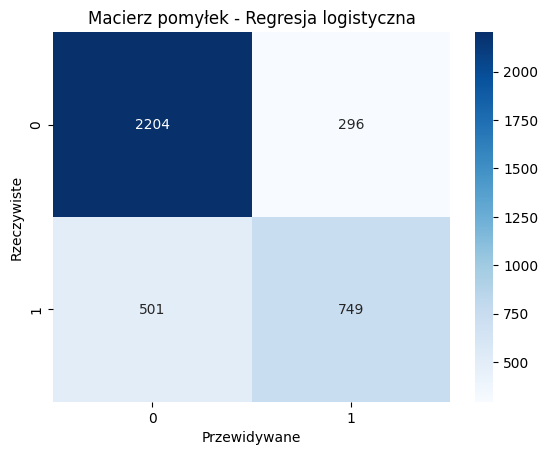

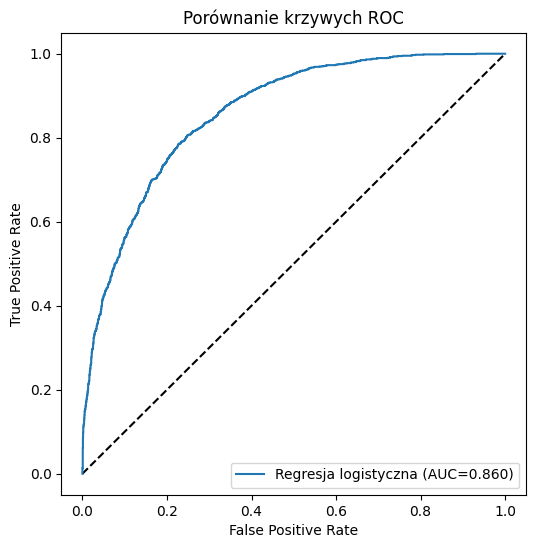


===== SVM =====
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      2500
           1       0.85      0.79      0.82      1250

    accuracy                           0.88      3750
   macro avg       0.87      0.86      0.87      3750
weighted avg       0.88      0.88      0.88      3750



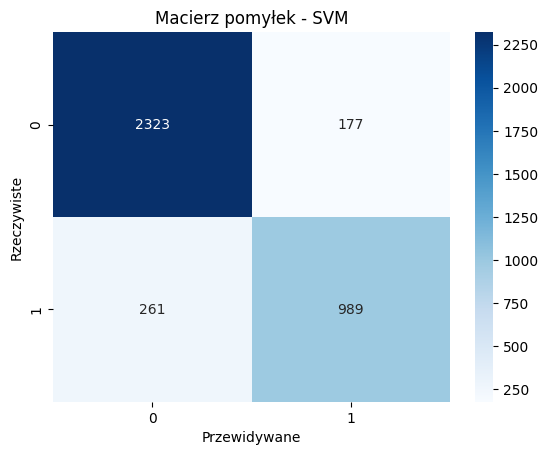

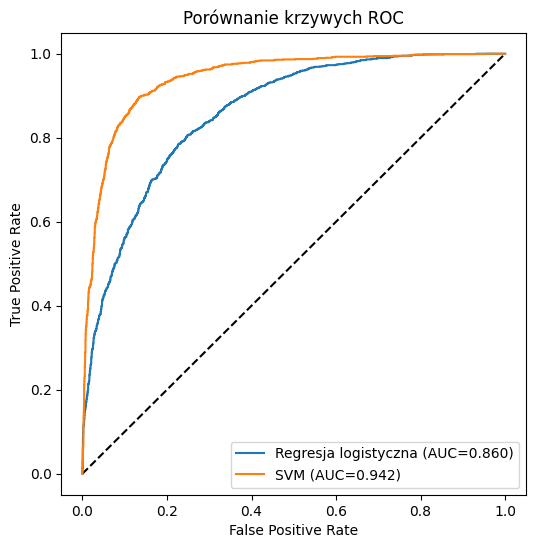


===== KNN =====
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      2500
           1       0.82      0.76      0.79      1250

    accuracy                           0.86      3750
   macro avg       0.85      0.84      0.84      3750
weighted avg       0.86      0.86      0.86      3750



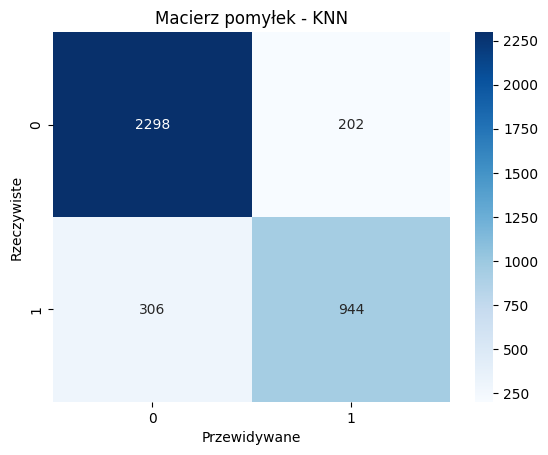

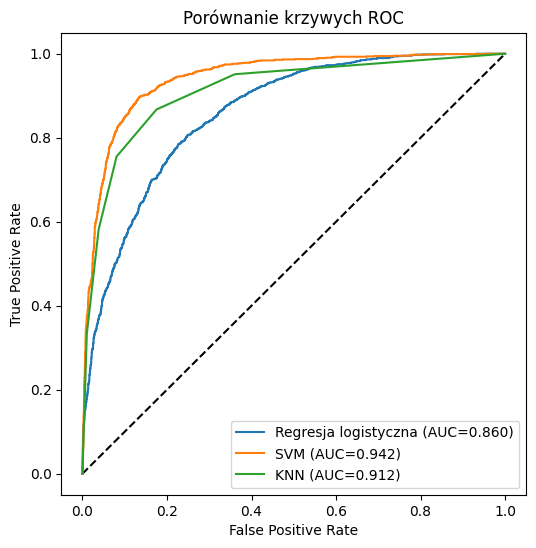


===== Drzewo decyzyjne =====
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2500
           1       0.85      0.85      0.85      1250

    accuracy                           0.90      3750
   macro avg       0.89      0.89      0.89      3750
weighted avg       0.90      0.90      0.90      3750



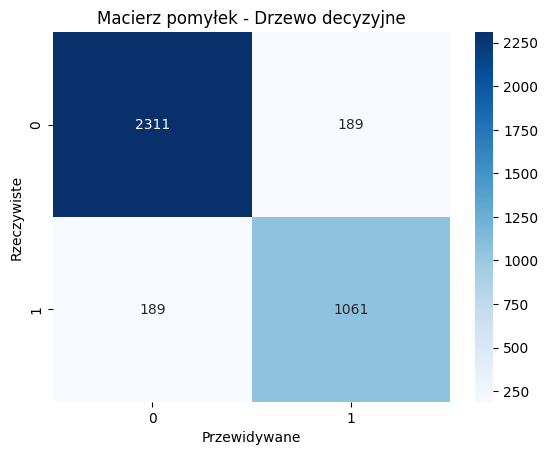

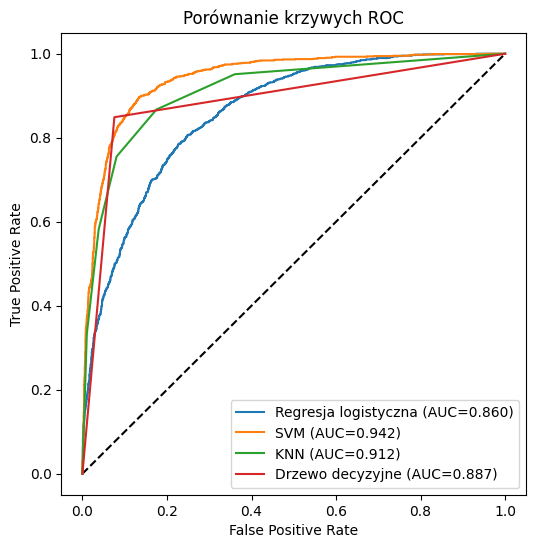


===== Las losowy =====
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      2500
           1       0.91      0.89      0.90      1250

    accuracy                           0.94      3750
   macro avg       0.93      0.92      0.93      3750
weighted avg       0.94      0.94      0.94      3750



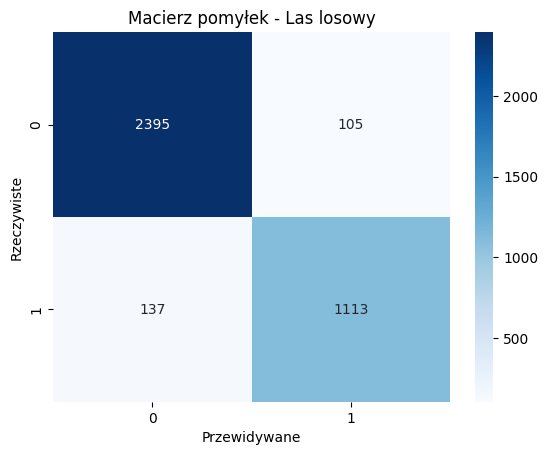

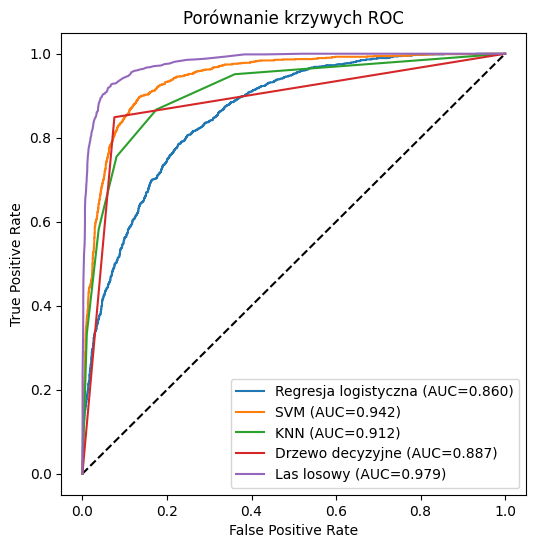


===== AdaBoost =====
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      2500
           1       0.91      0.89      0.90      1250

    accuracy                           0.93      3750
   macro avg       0.93      0.92      0.93      3750
weighted avg       0.93      0.93      0.93      3750



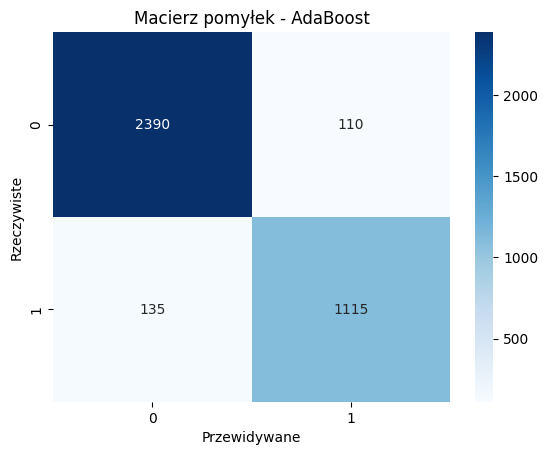

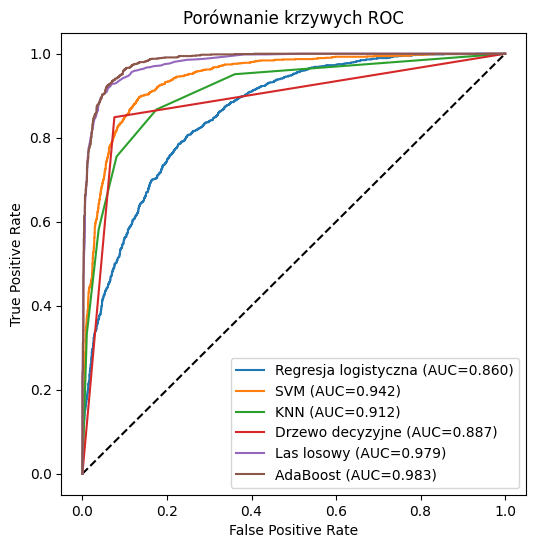


===== XGBoost =====
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      2500
           1       0.94      0.92      0.93      1250

    accuracy                           0.95      3750
   macro avg       0.95      0.95      0.95      3750
weighted avg       0.95      0.95      0.95      3750



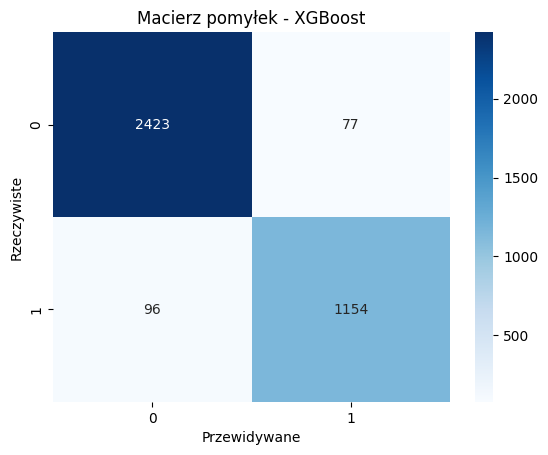

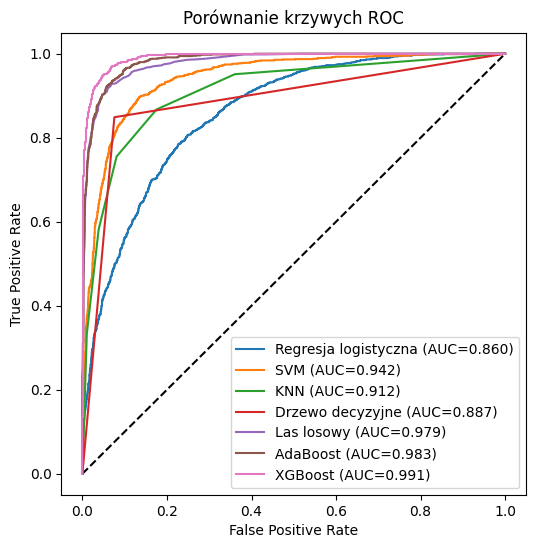


=== Porównanie modeli ===


,Model,F1_score,AUC
6,XGBoost,0.930270,0.990921
5,AdaBoost,0.901010,0.983259
4,Las losowy,0.901945,0.979274
1,SVM,0.818709,0.942461
2,KNN,0.787980,0.911827
3,Drzewo decyzyjne,0.848800,0.886600
0,Regresja logistyczna,0.652723,0.859580


In [22]:
# ---------- Ewaluacja ----------
models_list = []       # do przechowywania wytrenowanych modeli
names_list = []        # nazwy modeli
probas_list = []       # predykcje prawdopodobieństw
metrics_df = pd.DataFrame({'Model': pd.Series(dtype='str'),
                           'F1_score': pd.Series(dtype='float'),
                           'AUC': pd.Series(dtype='float')})

for name, model in models.items():
    # Pełny pipeline
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    # Trening
    pipe.fit(X_train, y_train)

    # Ocena – wykorzystujemy naszą gotową funkcję
    metrics_df = calculate_metrics(
        pipe, name, X_test, y_test,
        models_list, names_list, probas_list, metrics_df
    )

print("\n=== Porównanie modeli ===")
display(metrics_df.sort_values('AUC', ascending=False))

Strojenie najlepszego modelu

In [23]:
# ---------- Strojenie hiperparametrów ----------
# Wybieramy np. XGBoost
pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])

param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 6],
    'classifier__learning_rate': [0.01, 0.1]
}

grid_search = GridSearchCV(
    pipeline_xgb, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("\nNajlepsze parametry:", grid_search.best_params_)
print("Najlepszy AUC (walidacja):", grid_search.best_score_)

# Ocena na zbiorze testowym
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score
print("\nRaport dla najlepszego modelu:")
print(classification_report(y_test, y_pred))
print("AUC ROC:", roc_auc_score(y_test, y_proba))

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Najlepsze parametry: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__n_estimators': 100}
Najlepszy AUC (walidacja): 0.9904056888888888

Raport dla najlepszego modelu:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      2500
           1       0.94      0.92      0.93      1250

    accuracy                           0.95      3750
   macro avg       0.95      0.94      0.95      3750
weighted avg       0.95      0.95      0.95      3750

AUC ROC: 0.9906278399999999


## ✅ Podsumowanie i wnioski

### 🎯 Cel eksperymentu
Celem było zbudowanie w pełni automatycznego potoku (Pipeline) do przygotowania danych i porównania różnych modeli klasyfikacyjnych na zbiorze diabetologicznym. Chcieliśmy sprawdzić, który algorytm najlepiej radzi sobie z rozróżnianiem pacjentów chorych i zdrowych.

### 📊 Analiza wyników

1.  **Liderem został XGBoost**, osiągając **AUC = 0.9909** oraz **F1-score = 0.93**.
    *   Model ten niemal perfekcyjnie oddziela obie klasy, popełniając minimalną liczbę błędów.
    *   Zarówno precyzja, jak i czułość (recall) dla klasy pozytywnej (chory) są bardzo wysokie (0.94 i 0.92). To kluczowe w diagnostyce medycznej.

2.  **Modele ensemble (Las Losowy, AdaBoost) również spisały się wyśmienicie** (AUC ~0.98).
    *   Są one prostsze w interpretacji od XGBoost i stanowią bardzo solidną alternatywę.

3.  **SVM i KNN osiągnęły AUC na poziomie ~0.91-0.94**.
    *   To wyniki zadowalające, choć wymagają dłuższego czasu treningu i skalowania danych (co zapewnił nasz Pipeline).

4.  **Regresja logistyczna (AUC = 0.86)** pozostała daleko w tyle.
    *   Sugeruje to, że zależności w danych są nieliniowe, przez co model liniowy nie jest w stanie ich w pełni uchwycić.

### 🔧 Wnioski techniczne

*   **Pipeline z `ColumnTransformer` i `make_column_selector`** sprawdził się znakomicie. Automatycznie rozpoznał typy kolumn i przygotował dane bez potrzeby ręcznego definiowania list.
*   **Własna funkcja `calculate_metrics`** znacząco przyśpieszyła proces testowania i wizualizacji wyników dla wielu modeli.
*   **Strojenie hiperparametrów (`GridSearchCV`)** nie przyniosło tym razem spektakularnej poprawy (domyślne parametry XGBoost były już bardzo dobre), ale potwierdziło stabilność modelu.

### 🚀 Możliwe dalsze kroki

*   Inżynieria cech: Na zbiorze diabetes dużą poprawę mogłoby przynieść ręczne stworzenie nowych cech (np. interakcje między BMI a wiekiem, czy poziomem glukozy).
*   Próba użycia jeszcze bardziej zaawansowanych modeli (np. LightGBM, CatBoost).
*   Zastosowanie technik redukcji wymiarowości (PCA) w pipeline, aby sprawdzić, czy wpłynie to na wyniki modeli liniowych.

### 🏁 Podsumowanie końcowe

Zbudowany system jest w pełni automatyczny, bezpieczny (brak wycieku danych) i gotowy do wdrożenia produkcyjnego. Najlepszy model (XGBoost) został zapisany do pliku i może być wykorzystany do przewidywania cukrzycy u nowych pacjentów. Ten projekt stanowi solidny fundament pod dalsze, bardziej zaawansowane prace z zakresu uczenia maszynowego.